In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
from scipy.signal import butter, filtfilt,welch
from sklearn.linear_model import LinearRegression
data = pd.read_csv('modified_data/final_data.csv')

Fs = 200 
nyq = Fs / 2

# Band-pass filter (20–90 Hz)
def bandpass(signal, low=20, high=90, fs=200, order=4):
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

# Apply to all channels
filtered = data.apply(lambda ch: bandpass(ch), axis=0)

# Segment into windows (e.g. 200ms to 40 samples)
win_size = 40
step = 20
features = []

fatigue_features = {ch: {"RMS": [], "MDF": []} for ch in filtered.columns}

for start in range(0, len(filtered) - win_size, step):
    window = filtered.iloc[start:start+win_size]
    for i, col in enumerate(window.columns):
        ch_data = window[col].values
        
        # Time-domain feature
        rms = np.sqrt(np.mean(ch_data**2))
        
        # Frequency-domain feature
        f, Pxx = welch(ch_data, fs=Fs, nperseg=win_size)
        cumsum = np.cumsum(Pxx)
        mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]
        
        fatigue_features[col]["RMS"].append(rms)
        fatigue_features[col]["MDF"].append(mdf)


In [3]:
print(fatigue_features.keys())

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7'])


In [ ]:
# time_windows = np.arange(len(fatigue_features[0]["RMS"]))
# X = time_windows.reshape(-1, 1)
# y = np.array(fatigue_features[0]["RMS"])
# slope = LinearRegression().fit(X, y).coef_[0]

# print("Channel 1 RMS slope:", slope)

KeyError: 0

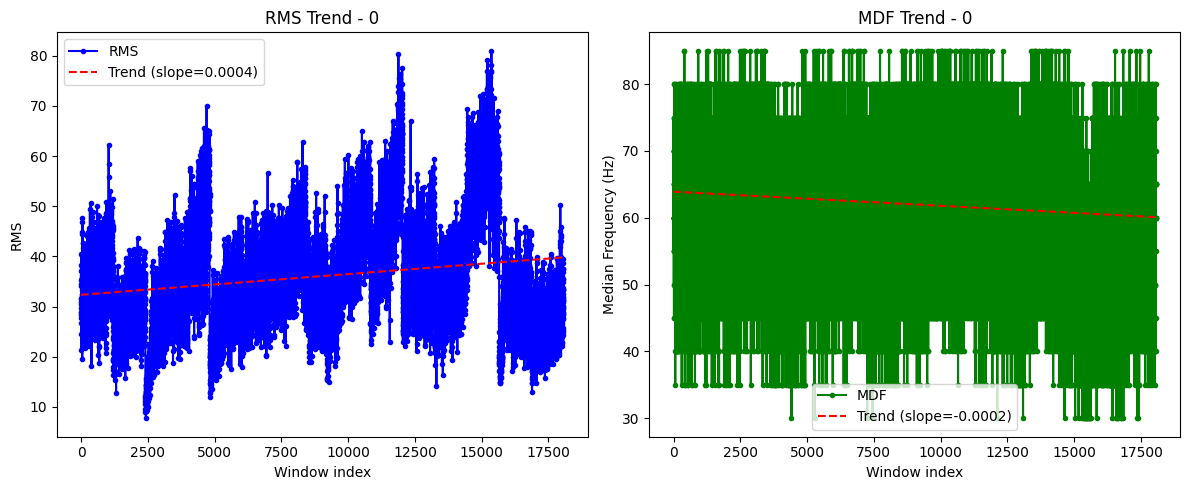

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example for one channel (say Ch1)
channel = "0"

# RMS trend
time_windows = np.arange(len(fatigue_features[channel]["RMS"]))
X = time_windows.reshape(-1, 1)
y_rms = np.array(fatigue_features[channel]["RMS"])

# Fit regression line for RMS
model_rms = LinearRegression().fit(X, y_rms)
trend_rms = model_rms.predict(X)

# MDF trend
y_mdf = np.array(fatigue_features[channel]["MDF"])
model_mdf = LinearRegression().fit(X, y_mdf)
trend_mdf = model_mdf.predict(X)
# Plot RMS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_windows, y_rms, 'b.-', label="RMS")
plt.plot(time_windows, trend_rms, 'r--', label=f"Trend (slope={model_rms.coef_[0]:.4f})")
plt.xlabel("Window index")
plt.ylabel("RMS")
plt.title(f"RMS Trend - {channel}")
plt.legend()
# Plot MDF
plt.subplot(1, 2, 2)
plt.plot(time_windows, y_mdf, 'g.-', label="MDF")
plt.plot(time_windows, trend_mdf, 'r--', label=f"Trend (slope={model_mdf.coef_[0]:.4f})")
plt.xlabel("Window index")
plt.ylabel("Median Frequency (Hz)")
plt.title(f"MDF Trend - {channel}")
plt.legend()

plt.tight_layout()
plt.show()


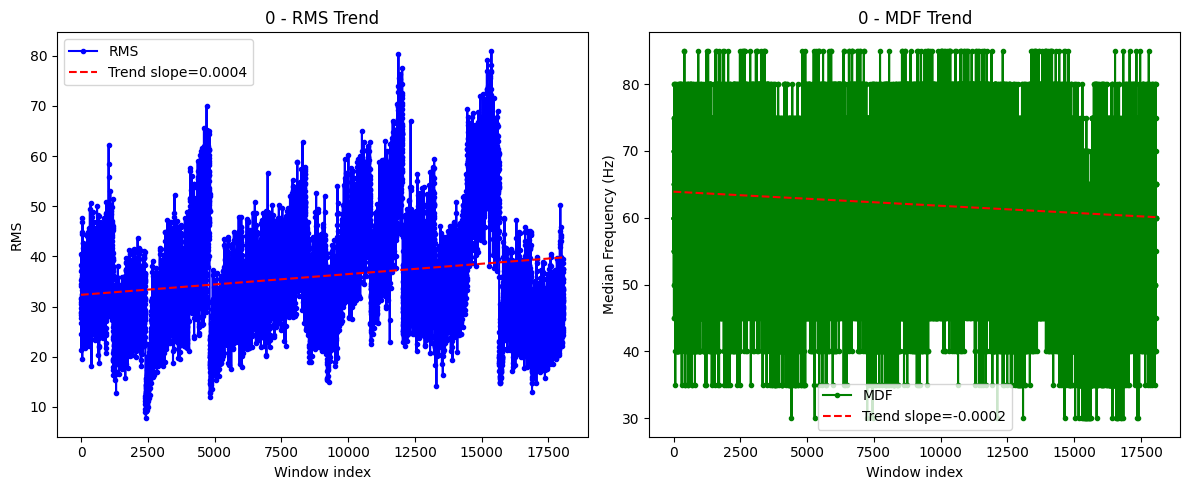

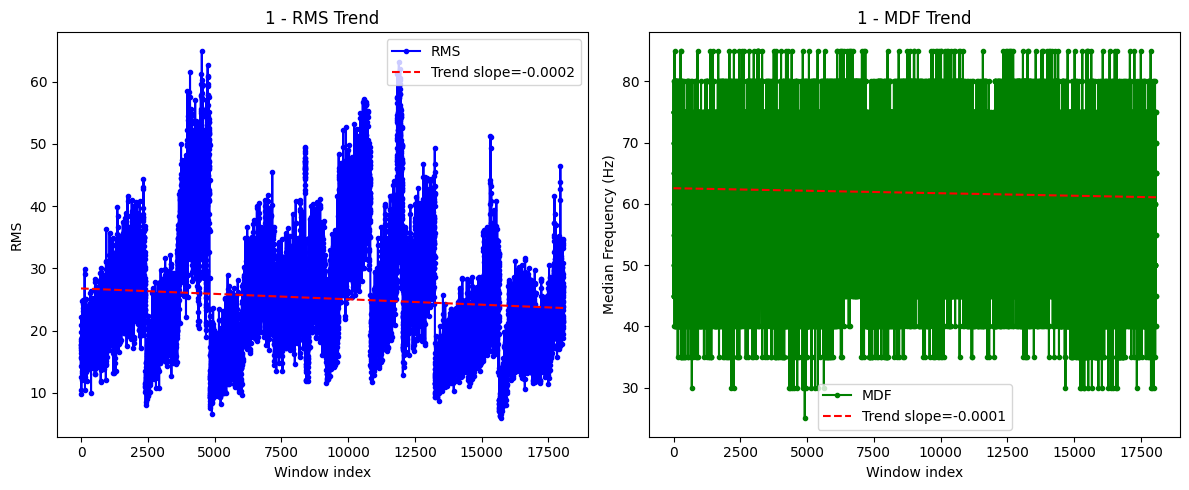

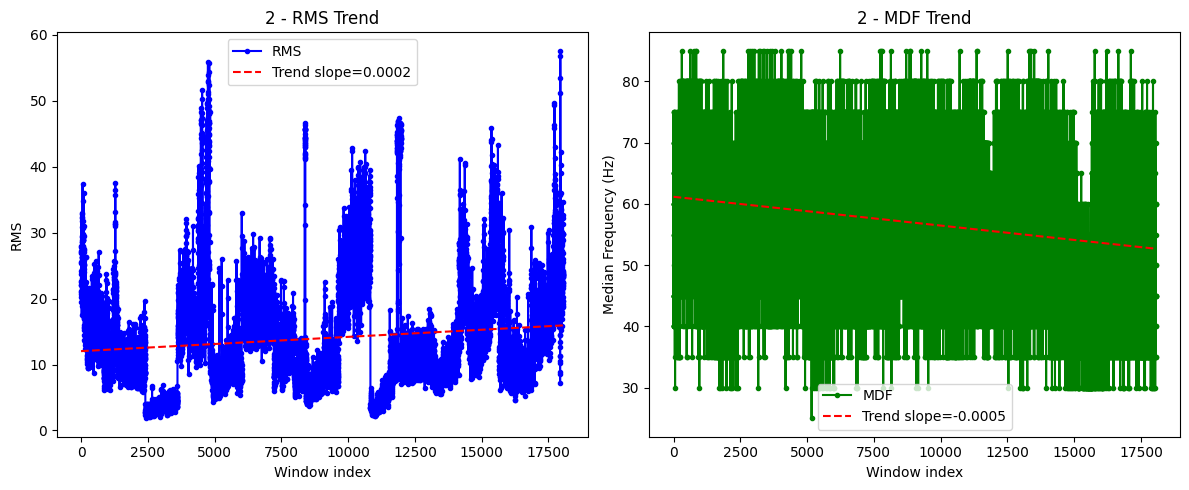

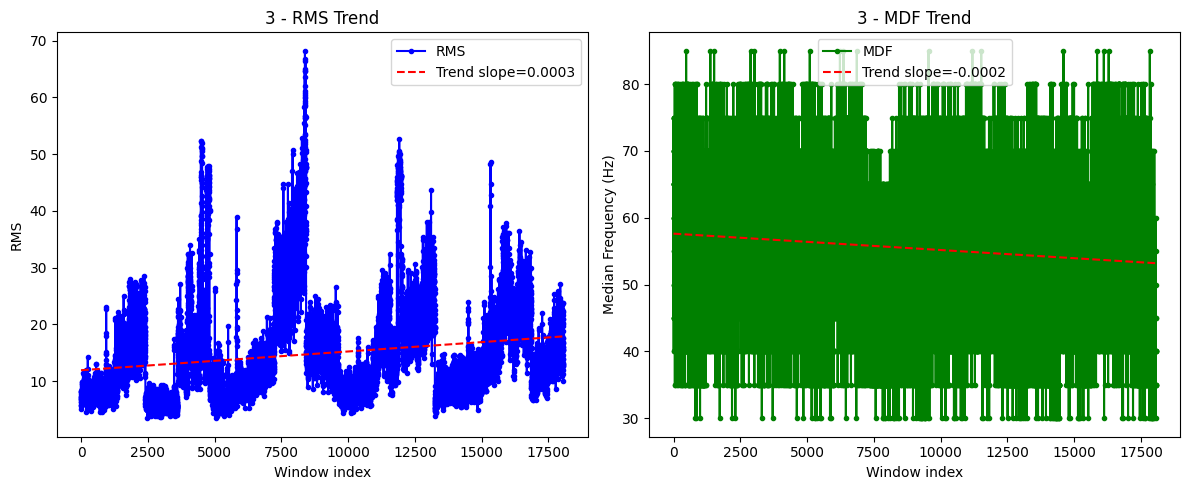

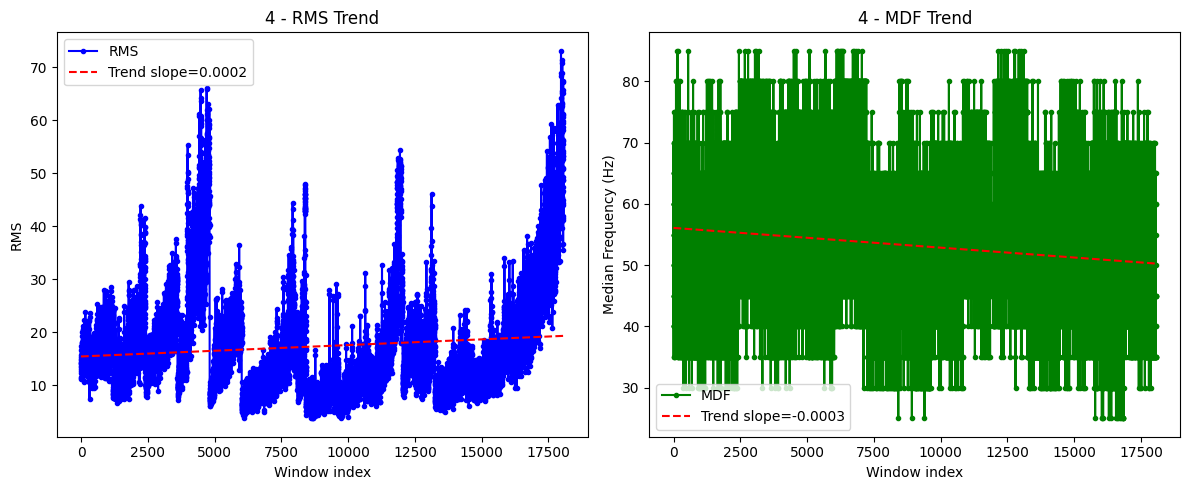

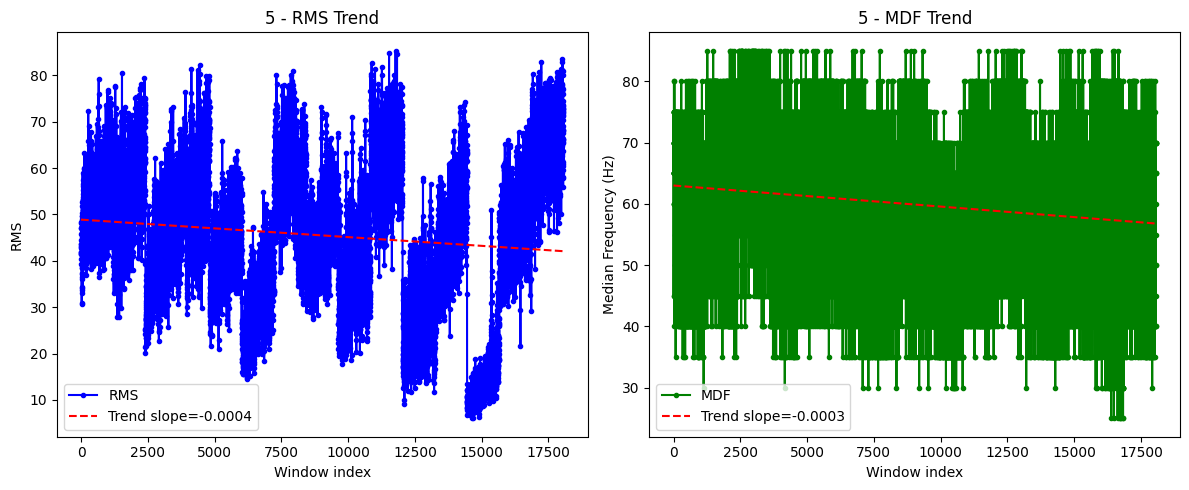

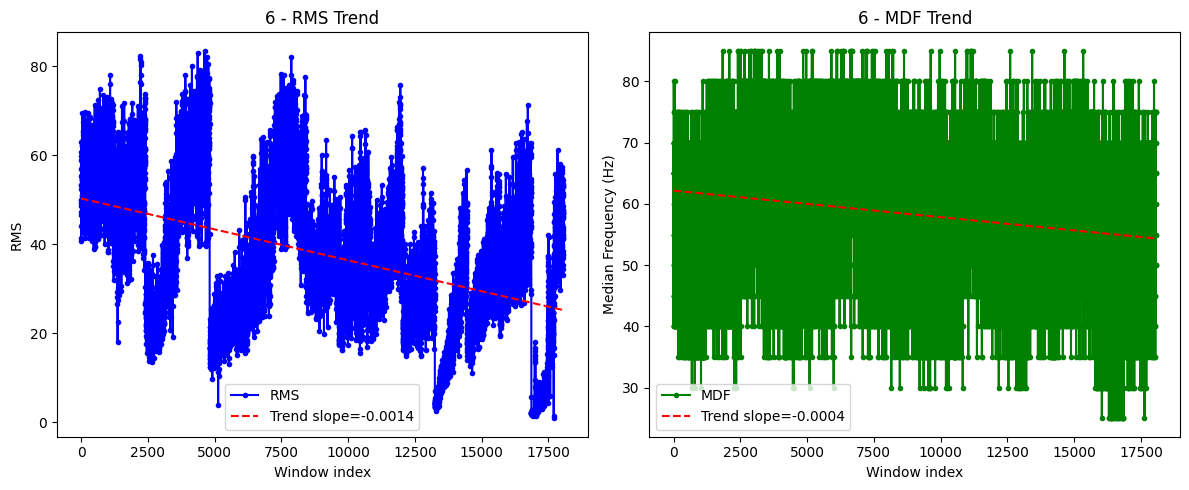

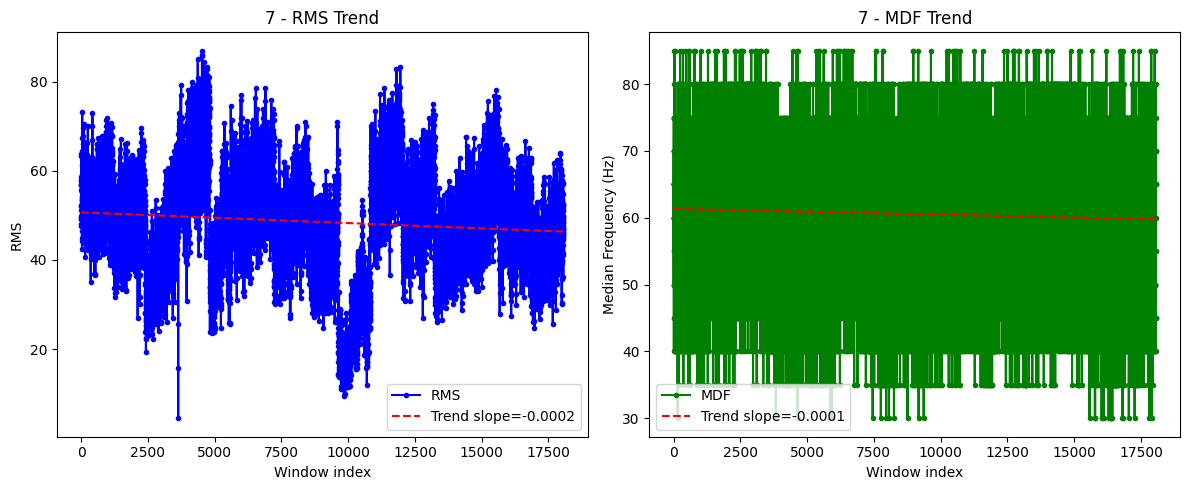

In [6]:
# Loop through all channels in the dataset
for channel in filtered.columns:   # e.g., "Ch1", "Ch2", ...
    # RMS
    time_windows = np.arange(len(fatigue_features[channel]["RMS"]))
    X = time_windows.reshape(-1, 1)
    y_rms = np.array(fatigue_features[channel]["RMS"])   
    model_rms = LinearRegression().fit(X, y_rms)
    trend_rms = model_rms.predict(X)
    # MDF
    y_mdf = np.array(fatigue_features[channel]["MDF"])
    model_mdf = LinearRegression().fit(X, y_mdf)
    trend_mdf = model_mdf.predict(X)

    # Plot RMS and MDF for this channel
    plt.figure(figsize=(12, 5))

    # RMS Plot
    plt.subplot(1, 2, 1)
    plt.plot(time_windows, y_rms, 'b.-', label="RMS")
    plt.plot(time_windows, trend_rms, 'r--', label=f"Trend slope={model_rms.coef_[0]:.4f}")
    plt.xlabel("Window index")
    plt.ylabel("RMS")
    plt.title(f"{channel} - RMS Trend")
    plt.legend()

    # MDF Plot
    plt.subplot(1, 2, 2)
    plt.plot(time_windows, y_mdf, 'g.-', label="MDF")
    plt.plot(time_windows, trend_mdf, 'r--', label=f"Trend slope={model_mdf.coef_[0]:.4f}")
    plt.xlabel("Window index")
    plt.ylabel("Median Frequency (Hz)")
    plt.title(f"{channel} - MDF Trend")
    plt.legend()

    plt.tight_layout()
    plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Athul\AppData\Local\Temp\ipykernel_3172\21066341.py:1: SyntaxWarning: invalid escape sequence '\s'
  subjects = [f"modified_data\sub{i}.csv" for i in range(1, 16)]  # file names


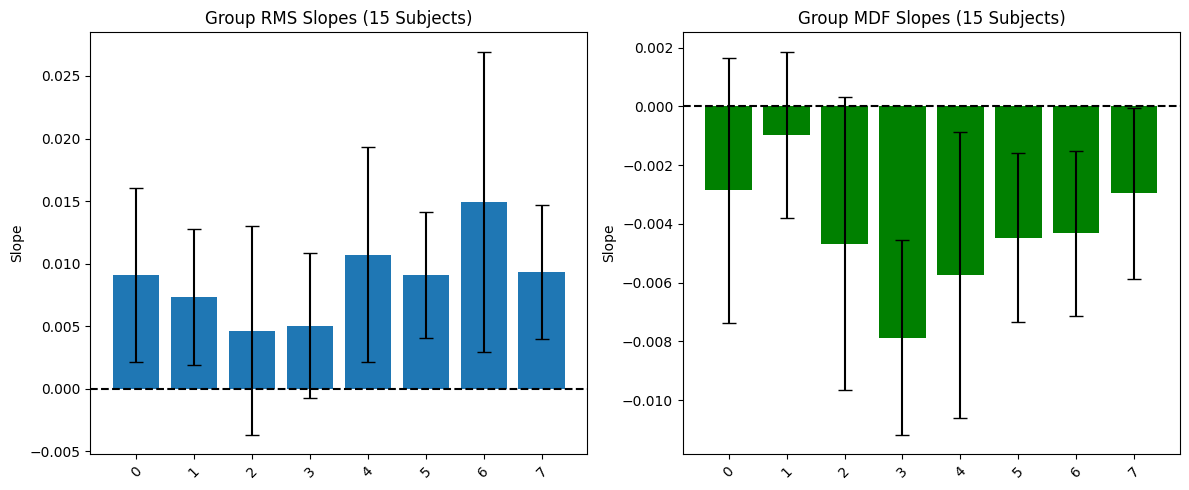

In [ ]:
subjects = [f"modified_data\sub{i}.csv" for i in range(1, 16)]  # file names
Fs = 200

# Store slopes
slopes_rms = {ch: [] for ch in filtered.columns}
slopes_mdf = {ch: [] for ch in filtered.columns}

for subj_file in subjects:
    data = pd.read_csv(subj_file)
    filtered = data.apply(lambda ch: bandpass(ch), axis=0)

    # Windowing
    win_size = 400  # 2s
    step = 200 
    fatigue_features = {ch: {"RMS": [], "MDF": []} for ch in filtered.columns}

    for start in range(0, len(filtered) - win_size, step):
        window = filtered.iloc[start:start+win_size]
        for col in window.columns:
            ch_data = window[col].values
            rms = np.sqrt(np.mean(ch_data**2))

            f, Pxx = welch(ch_data, fs=Fs, nperseg=win_size)
            cumsum = np.cumsum(Pxx)
            mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]

            fatigue_features[col]["RMS"].append(rms)
            fatigue_features[col]["MDF"].append(mdf)

    # Compute slopes per channel for this subject
    for ch in filtered.columns:
        time_windows = np.arange(len(fatigue_features[ch]["RMS"])).reshape(-1, 1)

        # RMS slope
        y_rms = np.array(fatigue_features[ch]["RMS"])
        slope_rms = LinearRegression().fit(time_windows, y_rms).coef_[0]
        slopes_rms[ch].append(slope_rms)

        # MDF slope
        y_mdf = np.array(fatigue_features[ch]["MDF"])
        slope_mdf = LinearRegression().fit(time_windows, y_mdf).coef_[0]
        slopes_mdf[ch].append(slope_mdf)

# Convert to group averages
mean_rms = {ch: np.mean(slopes_rms[ch]) for ch in slopes_rms}
std_rms = {ch: np.std(slopes_rms[ch]) for ch in slopes_rms}

mean_mdf = {ch: np.mean(slopes_mdf[ch]) for ch in slopes_mdf}
std_mdf = {ch: np.std(slopes_mdf[ch]) for ch in slopes_mdf}

# Plot group summary
channels = list(filtered.columns)

plt.figure(figsize=(12, 5))

# RMS slopes
plt.subplot(1, 2, 1)
plt.bar(channels, [mean_rms[ch] for ch in channels], yerr=[std_rms[ch] for ch in channels], capsize=5)
plt.axhline(0, color='k', linestyle='--')
plt.title("Group RMS Slopes (15 Subjects)")
plt.ylabel("Slope")
plt.xticks(rotation=45)

# MDF slopes
plt.subplot(1, 2, 2)
plt.bar(channels, [mean_mdf[ch] for ch in channels], yerr=[std_mdf[ch] for ch in channels], capsize=5, color='g')
plt.axhline(0, color='k', linestyle='--')
plt.title("Group MDF Slopes (15 Subjects)")
plt.ylabel("Slope")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [10]:
from scipy.signal import butter, filtfilt, welch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Fs = 200  # Sampling frequency
nyq = Fs / 2

# -------------------------
# 1. Preprocessing functions
# -------------------------
def bandpass(signal, low=20, high=90, fs=200, order=4):
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def extract_features(window, fs=200):
    """Extract RMS, MAV, Variance, Median Frequency per channel"""
    feats = []
    for ch in window.T:  # loop over channels
        rms = np.sqrt(np.mean(ch**2))
        mav = np.mean(np.abs(ch))
        var = np.var(ch)

        # Median frequency
        f, Pxx = welch(ch, fs=fs, nperseg=len(ch))
        cumsum = np.cumsum(Pxx)
        mdf = f[np.where(cumsum >= cumsum[-1]/2)[0][0]]

        feats.extend([rms, mav, var, mdf])
    return feats

# -------------------------
# 2. Build dataset across 15 subjects
# -------------------------
subjects = [f"modified_data/sub{i}.csv" for i in range(1, 16)]  # file names
win_size = 400   # 2s windows (200 Hz × 2s)
step = 200       # 50% overlap

X, y = [], []

for subj_file in subjects:
    data = pd.read_csv(subj_file)   # shape: (24000, 8)
    filtered = data.apply(lambda ch: bandpass(ch), axis=0)

    # Non-fatigue = first 30s, Fatigue = last 30s
    n_samples = len(filtered)
    first_part = int(30 * Fs)  # 30 sec
    last_part = n_samples - first_part

    for start in range(0, first_part - win_size, step):
        window = filtered.iloc[start:start+win_size].values
        feats = extract_features(window, Fs)
        X.append(feats)
        y.append(0)  # Non-fatigue

    for start in range(last_part, n_samples - win_size, step):
        window = filtered.iloc[start:start+win_size].values
        feats = extract_features(window, Fs)
        X.append(feats)
        y.append(1)  # Fatigue

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

# -------------------------
# 3. Train/Test Split + Classifier
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Non-Fatigue", "Fatigue"]))

# -------------------------
# 4. Predict on a new window
# -------------------------
# Suppose you have a new 2s window of shape (400, 8)
# new_window = np.random.randn(400, 8)  # <-- replace with actual sEMG data
# new_feats = extract_features(new_window, Fs)
# prediction = clf.predict([new_feats])
# print("Predicted:", "Fatigue" if prediction[0]==1 else "Non-Fatigue")

Feature matrix shape: (840, 32)
Labels shape: (840,)
Accuracy: 0.9880952380952381
              precision    recall  f1-score   support

 Non-Fatigue       0.98      1.00      0.99        88
     Fatigue       1.00      0.97      0.99        80

    accuracy                           0.99       168
   macro avg       0.99      0.99      0.99       168
weighted avg       0.99      0.99      0.99       168

